# Explore here

In [ ]:
#los "imports"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_classif

import pickle

from pickle import dump

In [2]:
#Importar la data a CSV
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
pd.read_csv(url).to_csv('../data/diabetes.csv', index=False)

In [3]:
#Cargamos el CSV y mostramos las primeras filas del DataFrame
df = pd.read_csv("../data/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#Tamaño y dimensiones del DataFrame
df.shape

(768, 9)

In [5]:
#Resumen del DataFrame (estructura y tipo de datos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Todos los aspectos anteriores en la base de datos son aspectos que influyen al estudiar la diabetes.

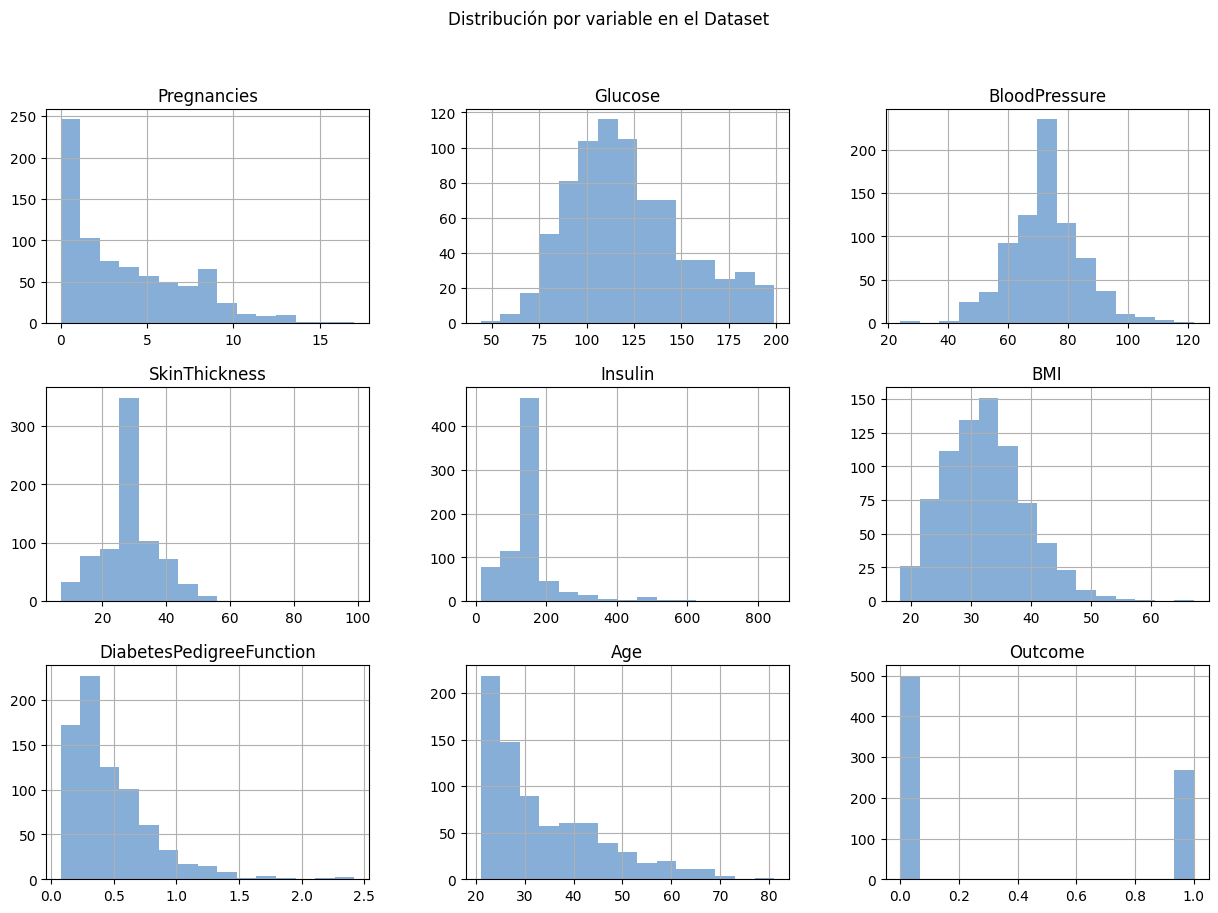

In [39]:
#Graficar cada una de las entradas anteriores, para ver cómo se comportan.
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(bins=15, figsize=(15, 10), color="#87AED7")
plt.suptitle("Distribución por variable en el Dataset")
plt.show()

In [7]:
#Revisamos valores dentro del Dataset
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

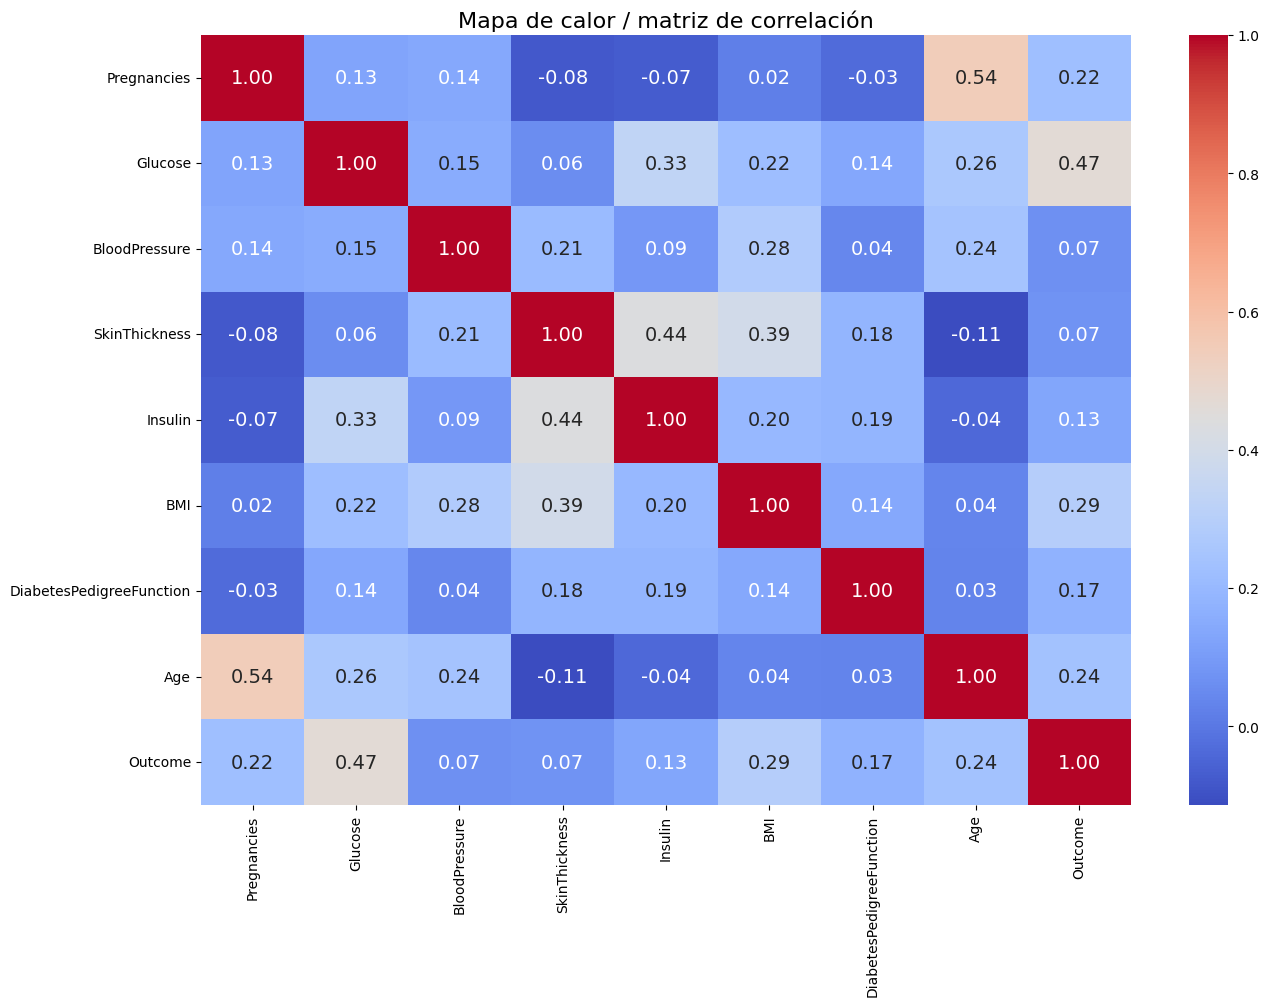

In [8]:
#Generamos un mapa de calor para poder visualizar la correlación entre ellos
corr = df[num_cols].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 14})
plt.title("Mapa de calor / matriz de correlación", fontsize=16)
plt.show()

Este mapa de calor muestra los datos tal cual aparecen en el Dataset, a continuación comencaremos a limpiar datos y a mejorar si es posible, para tener un mejor análisis.

In [9]:
#Los valores en 0 los remplazaremos, y utilizaremos la mediana para llenar esos espacios imaginando que los valores de la mediana son los "normales" entre los pacientes
cols_cero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_cero] = df[cols_cero].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")
df[cols_cero] = imputer.fit_transform(df[cols_cero])

En el punto anterior, dentro de los datos de glucosa, presión sanguinea, espesor de piel, etc. había datos en 0, que si cogemos una presión sanguinea de 0 es que el paciente está muerto, o una piel de 0 ml de grosor, por ende son erroneos, como dejo nota anterior, se elige la mediana para suplir los datos en 0.

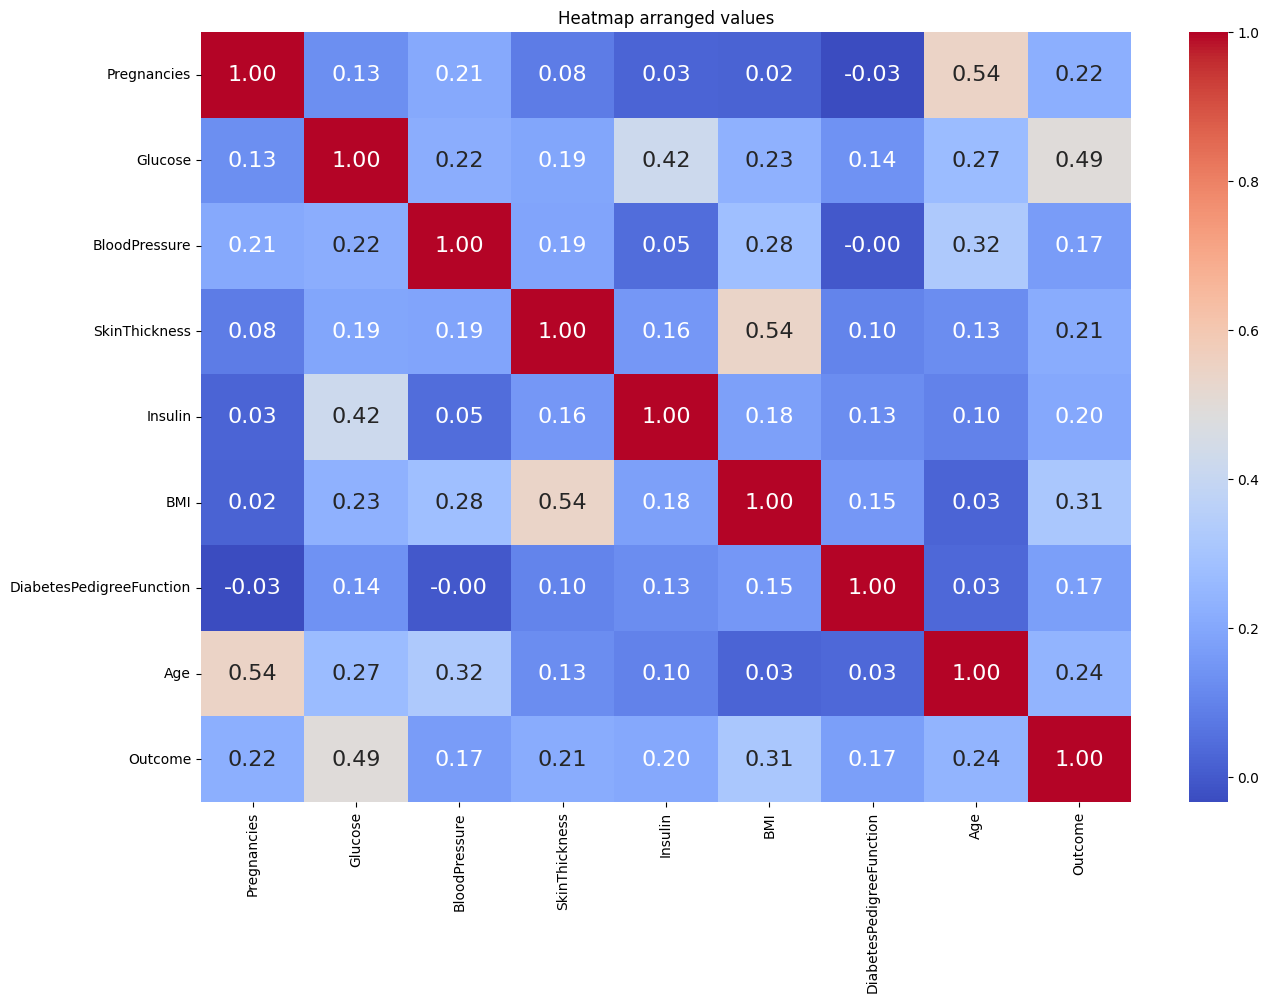

In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 16})
plt.title("Heatmap arranged values")
plt.show()

Ahora hay datos que tienen mejor correlación...

/tmp/ipykernel_1482/2243161451.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='Glucose', palette=["#87AED7","#EAA793"])


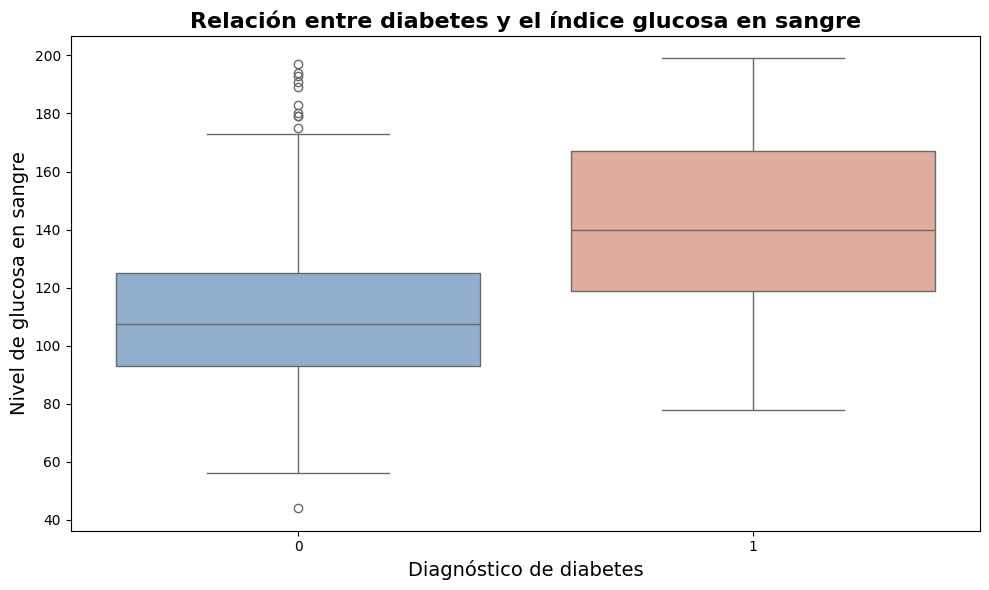

In [36]:
#Con un gráfico de bloxplot mostramos una relación entre la diabetes y el índice de glucosa en sangre
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Outcome', y='Glucose', palette=["#87AED7","#EAA793"])
plt.title("Relación entre diabetes y el índice glucosa en sangre", fontsize=16, fontweight='bold')
plt.xlabel("Diagnóstico de diabetes", fontsize=14)
plt.ylabel("Nivel de glucosa en sangre", fontsize=14)
plt.tight_layout()
plt.show()

En la gráfica se puede apreciar la relación que existe entre el nivel de glucosa en la sangre de un paciente que tiene diagnosticada diabetes, según la información que se encuentra de manera generalizada en internet, se indica que, "Se considera diabetes cuando los niveles de glucosa en sangre en ayunas son \(126\) mg/dL", si bien en este Dataset no hay una especificación sobre el nivel de glucosa en la sangre (en qué momento se toma esa muestra) tenemos en cambio un conteo general. Entonces, podemos ver que aquellos con un indice superior a 125 (a ojo) estan en el lado de los que están diagnósticados con diabetes, los que están en el grupo 0 (que no tienen diabetes) rondan entre 86/125 mg/dL.

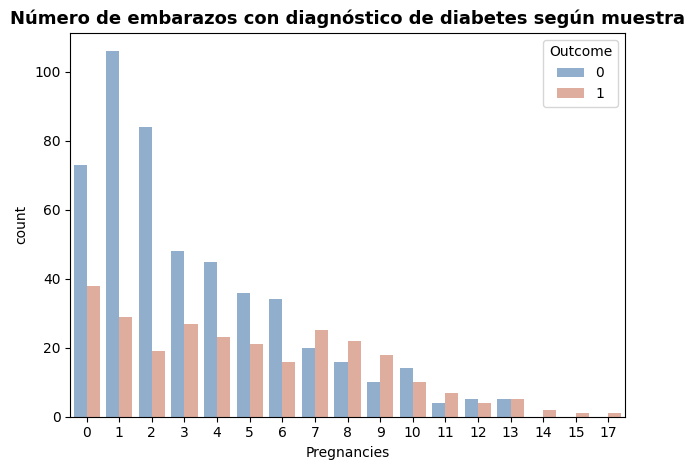

In [35]:
#Correlación entre embarazo y diabetes (Diabetes gestacional)
sns.countplot(x="Pregnancies", hue="Outcome", data=df, palette=["#87AED7","#EAA793"])
plt.title("Número de embarazos con diagnóstico de diabetes según muestra", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


En el gráfico se puede ver que, a mayor número de embarazos aumenta el diagóstico de diabetes, y es que, en el embarazo al haber un cambio hormonal en el cuerpo de la madre, esto puede interferir en el trabajo correcto de la insulina y por ende aumente el azúcar en la sangre...

In [42]:
#Comenzamos entrenamiento
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,72.0,29.0,125.0,32.3,0.304,21
618,9,112.0,82.0,24.0,125.0,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,29.0,125.0,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46


In [ ]:
#Se verifica que sea una distribución correcta
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [ ]:
#Guardado del dataset separado
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)
y_train_df = pd.DataFrame(y_train)
y_test_df = pd.DataFrame(y_test)

X_train_df.to_csv('X_train.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
y_train_df.to_csv('y_train.csv', index=False)
y_test_df.to_csv('y_test.csv', index=False)

with open('dataset.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

In [45]:
#Entrenamiento + uso de árbol de decisiones
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [86]:
#Diseño de árbol de desiciones
model = DecisionTreeClassifier(max_depth=3, min_samples_split=2,  random_state = 42, min_samples_leaf=5)
# entrenamiento
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [87]:
#predicción en prueba
y_pred_test = model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [88]:
# predicción en entrenamiento
y_pred_test = model.predict(X_train)
y_pred_test

array([0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,

In [91]:
# Predicciones en train y test
y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

In [92]:
#Calculo de métricas de evaluación en el modelo en prueba y entrenamiento.
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

f1_score_test = f1_score(y_test, y_pred_test, average='micro')
f1_score_train = f1_score(y_train, y_pred_train, average='micro')

precision_test = precision_score(y_test, y_pred_test, average='micro')
precision_train = precision_score(y_train, y_pred_train, average='micro')

recall_test = recall_score(y_test, y_pred_test, average='micro')
recall_train = recall_score(y_train, y_pred_train, average='micro')

print("Accuracy Test: ", accuracy_test)
print("F1 score Test: ", f1_score_test)
print("Precision Test: ", precision_test)
print("Recall Test: ", recall_test)

print("Accuracy Train: ", accuracy_train)
print("F1 score Train: ", f1_score_train)
print("Precision Train: ", precision_train)
print("Recall Train: ", recall_train)

Accuracy Test:  0.7012987012987013
F1 score Test:  0.7012987012987013
Precision Test:  0.7012987012987013
Recall Test:  0.7012987012987013
Accuracy Train:  1.0
F1 score Train:  1.0
Precision Train:  1.0
Recall Train:  1.0


Bien en entrenamiento mal en prueba... sobreajuste =_____=

In [93]:
print(classification_report(y_test, y_pred_test,))

              precision    recall  f1-score   support

           0       0.77      0.76      0.77        99
           1       0.58      0.60      0.59        55

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.70      0.70      0.70       154



In [95]:
#Guardado de modelo
with open('../models/decision_tree_model.pkl', 'wb') as archive:
    pickle.dump(tree, archive)
